In [1]:
# Cell 1 — Discover SMMR yearly files (advance_YYYY / retreat_YYYY inside each)

import os, re, glob
import xarray as xr
import numpy as np

# ---- EDIT: folder containing SMMR NetCDFs ----
DATA_DIR = "/Users/fridaperez/Developer/repos/sea-ice-phase/results/SMMR_phase/"
GLOB_PAT = os.path.join(DATA_DIR, "*.nc")
# ----------------------------------------------

# SMMR mission years (adjust if your set is different)
YEARS = list(range(1979, 2025))  # 1979–1988 inclusive

# Find all candidate files
all_files = sorted(glob.glob(GLOB_PAT))

# Map each year -> file path by regexing a 4-digit year in filename
year_re = re.compile(r"(19|20)\d{2}")
year_to_path = {}
for f in all_files:
    m = year_re.search(os.path.basename(f))
    if not m:
        continue
    y = int(m.group(0))
    if y in YEARS and y not in year_to_path:
        year_to_path[y] = f  # first match wins; change if you prefer last

print("Discovered files for years:")
for y in YEARS:
    print(f"  {y}: {year_to_path.get(y, 'MISSING')}")

# Quick peek at variable names in the first available file
def list_phase_vars(nc_path):
    with xr.open_dataset(nc_path) as ds:
        return list(ds.data_vars)

first_path = next((year_to_path[y] for y in YEARS if y in year_to_path), None)
if first_path:
    print("\nExample variables in:", os.path.basename(first_path))
    print(list_phase_vars(first_path))
else:
    print("\nNo matching files found. Check DATA_DIR / pattern / YEARS.")

Discovered files for years:
  1979: /Users/fridaperez/Developer/repos/sea-ice-phase/results/SMMR_phase/seaice_phases_SMMR_1979.nc
  1980: /Users/fridaperez/Developer/repos/sea-ice-phase/results/SMMR_phase/seaice_phases_SMMR_1980.nc
  1981: /Users/fridaperez/Developer/repos/sea-ice-phase/results/SMMR_phase/seaice_phases_SMMR_1981.nc
  1982: /Users/fridaperez/Developer/repos/sea-ice-phase/results/SMMR_phase/seaice_phases_SMMR_1982.nc
  1983: /Users/fridaperez/Developer/repos/sea-ice-phase/results/SMMR_phase/seaice_phases_SMMR_1983.nc
  1984: /Users/fridaperez/Developer/repos/sea-ice-phase/results/SMMR_phase/seaice_phases_SMMR_1984.nc
  1985: /Users/fridaperez/Developer/repos/sea-ice-phase/results/SMMR_phase/seaice_phases_SMMR_1985.nc
  1986: /Users/fridaperez/Developer/repos/sea-ice-phase/results/SMMR_phase/seaice_phases_SMMR_1986.nc
  1987: /Users/fridaperez/Developer/repos/sea-ice-phase/results/SMMR_phase/seaice_phases_SMMR_1987.nc
  1988: /Users/fridaperez/Developer/repos/sea-ice-phas

In [2]:
# Cell 2 — Load advance/retreat across 1979–2023 into ('time','y','x')

YEARS = list(range(1979, 2024)) 

adv_list = []
ret_list = []

for y in YEARS:
    path = year_to_path.get(y)
    if path is None:
        print(f"Skipping {y} (no file found)")
        continue

    with xr.open_dataset(path) as ds:
        adv_var = f"advance_{y}"
        ret_var = f"retreat_{y}"
        if adv_var not in ds or ret_var not in ds:
            print(f"Warning: {os.path.basename(path)} missing {adv_var} or {ret_var}")
            continue

        # Ensure the same (y,x) layout and attach a time coord = year
        adv_list.append(ds[adv_var].expand_dims(time=[y]))
        ret_list.append(ds[ret_var].expand_dims(time=[y]))

# Concatenate along 'time'
adv_all = xr.concat(adv_list, dim="time")
ret_all = xr.concat(ret_list, dim="time")

print("Advance stacked:", adv_all.dims, adv_all.shape)
print("Retreat stacked:", ret_all.dims, ret_all.shape)
print("Years loaded:", adv_all.time.values)

Advance stacked: ('time', 'y', 'x') (45, 332, 316)
Retreat stacked: ('time', 'y', 'x') (45, 332, 316)
Years loaded: [1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992
 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006
 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020
 2021 2022 2023]


In [8]:
# Cell 3 — Build 8-feature matrix per pixel (N,8)

import numpy as np
import xarray as xr

P = 365.0
TAU = 2*np.pi
MIN_YEARS = 25   # require at least this many valid years per pixel

def doy_to_angle(d):
    return (TAU / P) * (d % P)

def circ_mean_cos_sin(theta):
    # returns (cos_bar, sin_bar) along time
    c = np.cos(theta).mean("time", skipna=True)
    s = np.sin(theta).mean("time", skipna=True)
    return c, s

def resultant_length(cbar, sbar):
    return np.hypot(cbar, sbar)  # R in [0,1]

def circ_diff_days(ret, adv, period=P):
    # per-year season length as circular difference in days
    return (ret - adv) % period

def count_finite(da):
    # count non-NaN values along time
    return da.notnull().sum("time")


# 1) Angles per year
Aθ = doy_to_angle(adv_all)   # (time,y,x)
Rθ = doy_to_angle(ret_all)

# 2) Circular means over years (climatology)
cosA_bar, sinA_bar = circ_mean_cos_sin(Aθ)  # (y,x)
cosR_bar, sinR_bar = circ_mean_cos_sin(Rθ)

# 3) Interannual concentration (stability of timing)
RA = resultant_length(cosA_bar, sinA_bar)   # (y,x)
RR = resultant_length(cosR_bar, sinR_bar)   # (y,x)

# 4) Season length stats (per year, then mean/std across years)
dur_yearly = circ_diff_days(ret_all, adv_all)   # (time,y,x)
mu_dur = dur_yearly.mean("time", skipna=True)   # (y,x)
sd_dur = dur_yearly.std("time", skipna=True)    # (y,x)

# 5) Validity mask: enough years for all three quantities
valid_A = count_finite(adv_all) >= MIN_YEARS
valid_R = count_finite(ret_all) >= MIN_YEARS
valid_D = count_finite(dur_yearly) >= MIN_YEARS
valid_mask = (valid_A & valid_R & valid_D)

# 6) Pack features into (y,x,feat)
feat_da = xr.concat(
    [cosA_bar, sinA_bar, cosR_bar, sinR_bar, RA, RR, mu_dur, sd_dur],
    dim="feat"
).transpose("y","x","feat")
feat_da = feat_da.assign_coords(feat=["cosμA","sinμA","cosμR","sinμR","R_A","R_R","μ_dur","σ_dur"])

# 7) Final finite mask and flatten to (N,8)
finite_mask = np.isfinite(feat_da).all("feat")
mask_grid = (valid_mask & finite_mask)

vals = feat_da.values                         # (Y, X, 8)
Y, Xn, F = vals.shape
flat = vals.reshape(Y*Xn, F)
mask_vec = mask_grid.values.reshape(Y*Xn)

X8 = flat[mask_vec]                           # (N, 8)

def grid_from_vector(vec, mask_boolean):
    out = np.full(mask_boolean.shape, np.nan, dtype=float)
    out[mask_boolean] = vec
    return out

print("Feature names:", list(feat_da.feat.values))
print("X8 shape (N,8):", X8.shape)
print("Valid pixel fraction:", float(mask_grid.mean().values))
print("Example row:", X8[0])


Feature names: [np.str_('cosμA'), np.str_('sinμA'), np.str_('cosμR'), np.str_('sinμR'), np.str_('R_A'), np.str_('R_R'), np.str_('μ_dur'), np.str_('σ_dur')]
X8 shape (N,8): (28209, 8)
Valid pixel fraction: 0.2688824919932896
Example row: [ -0.65156081  -0.71467132  -0.56794944  -0.74239259   0.96710216
   0.93472633 179.19230769 158.37662493]


/Users/fridaperez/miniconda3/envs/seaice/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [9]:
# Cell 4 — Scale features, select K by BIC, fit GMM, map to grid

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

# X8: (N,8); mask_grid: (y,x) bool

# Optional: clip extreme duration stats to avoid a few pixels dominating
X8_clip = X8.copy()
# clip μ_dur (col 6) to [30, 330], σ_dur (col 7) to [0, 180]
X8_clip[:, 6] = np.clip(X8_clip[:, 6], 30, 330)
X8_clip[:, 7] = np.clip(X8_clip[:, 7], 0, 180)

# Standardize all features (cos/sin, R's, duration stats)
scaler = StandardScaler()
Xz = scaler.fit_transform(X8_clip)

# BIC sweep
Ks = range(2, 9)
bics = []
best_bic = np.inf
best = None

for K in Ks:
    gmm = GaussianMixture(
        n_components=K,
        covariance_type="full",
        n_init=5,
        random_state=42
    )
    gmm.fit(Xz)
    bic = gmm.bic(Xz)
    bics.append(bic)
    if bic < best_bic:
        best_bic = bic
        best = gmm

print("Ks:", list(Ks))
print("BICs:", bics)
print("Best K:", best.n_components)

# Cluster outputs
labels = best.predict(Xz)
probs  = best.predict_proba(Xz)
uncert = 1.0 - probs.max(axis=1)

# Map back to grid
def grid_from_vector(vec, mask_boolean):
    out = np.full(mask_boolean.shape, np.nan, dtype=float)
    out[mask_boolean] = vec
    return out

labels_grid = grid_from_vector(labels, mask_grid)
uncert_grid = grid_from_vector(uncert, mask_grid)

print("labels_grid:", labels_grid.shape, "uncert_grid:", uncert_grid.shape)


Ks: [2, 3, 4, 5, 6, 7, 8]
BICs: [np.float64(245662.48641810488), np.float64(138356.88172380152), np.float64(64675.50274224902), np.float64(12060.76071505217), np.float64(-19196.541594912123), np.float64(-49646.185289391564), np.float64(-79788.24465347883)]
Best K: 8
labels_grid: (332, 316) uncert_grid: (332, 316)


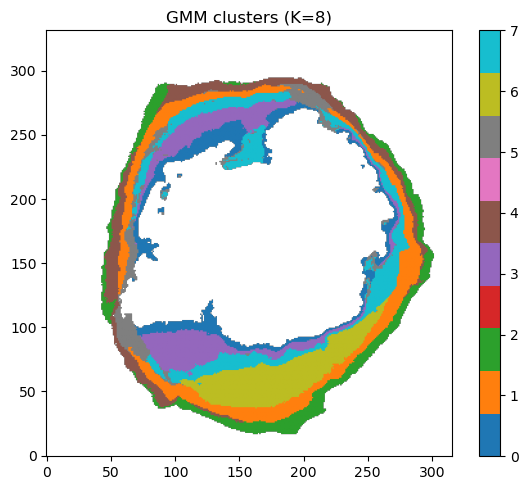

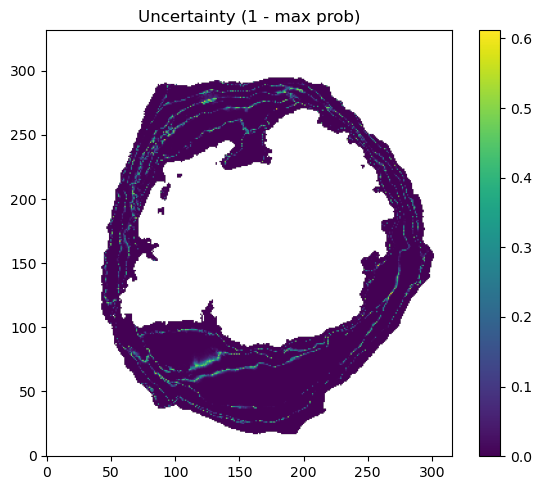

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
im = plt.imshow(labels_grid, origin="lower", cmap="tab10")
plt.title(f"GMM clusters (K={best.n_components})")
plt.colorbar(im); plt.tight_layout()

plt.figure(figsize=(6,5))
im2 = plt.imshow(uncert_grid, origin="lower", cmap="viridis")
plt.title("Uncertainty (1 - max prob)")
plt.colorbar(im2); plt.tight_layout()


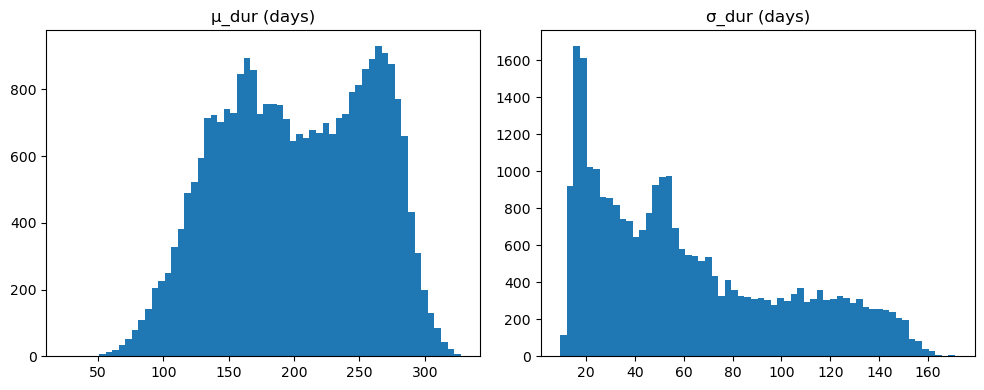

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].hist(X8[:,6], bins=60); ax[0].set_title("μ_dur (days)")
ax[1].hist(X8[:,7], bins=60); ax[1].set_title("σ_dur (days)")
plt.tight_layout()


In [12]:
X6 = X8[:, :6]
X6z = StandardScaler().fit_transform(X6)
bics6 = []
best6, best_bic6 = None, np.inf
for K in Ks:
    g = GaussianMixture(n_components=K, covariance_type="full", n_init=5, random_state=42).fit(X6z)
    b = g.bic(X6z); bics6.append(b)
    if b < best_bic6: best_bic6, best6 = b, g
print("Best K (6-feature set):", best6.n_components)


Best K (6-feature set): 8


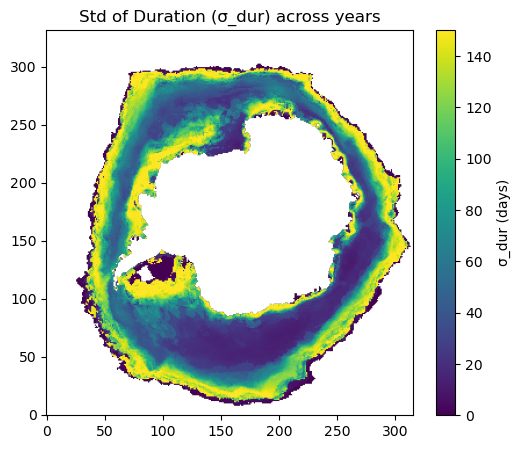

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
im = plt.imshow(sd_dur, origin="lower", cmap="viridis", vmin=0, vmax=150)
plt.colorbar(im, label="σ_dur (days)")
plt.title("Std of Duration (σ_dur) across years")
plt.show()


Tested Ks: [2, 3, 4, 5, 6, 7, 8, 9]
BICs: [np.float64(255203.5836670085), np.float64(147526.06789060056), np.float64(71970.39642636011), np.float64(7049.710125880105), np.float64(-25946.00208546677), np.float64(-71740.86405477597), np.float64(-96467.68532424117), np.float64(-122892.01888458693)]
Best K: 9
labels_grid: (332, 316)
uncert_grid: (332, 316)


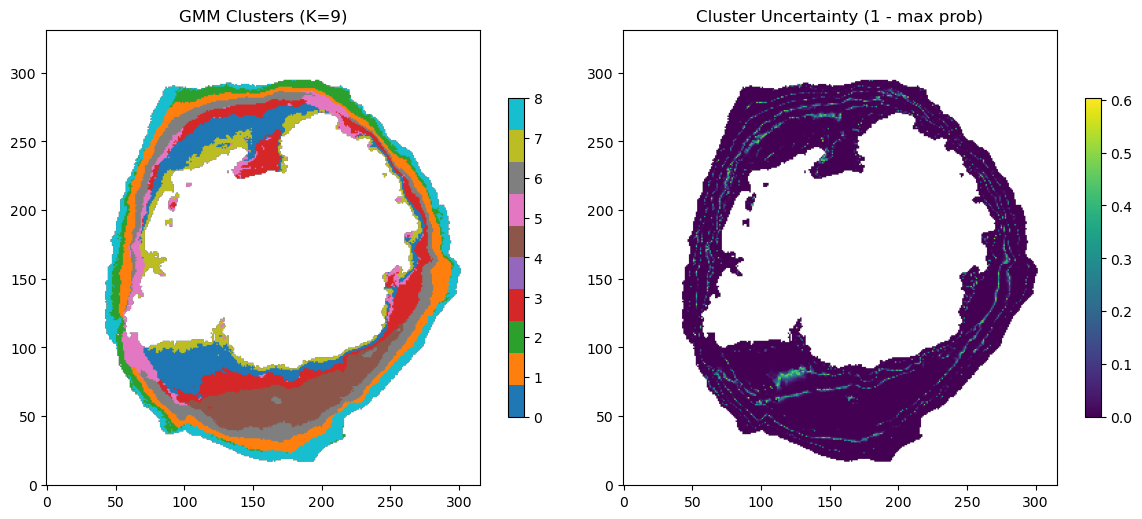

In [14]:
# Cell 4 — GMM clustering with 8 features (σ_dur clipped)

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# --- 1. Clip σ_dur to avoid outliers ---
X8_clip = X8.copy()
X8_clip[:, 7] = np.clip(X8_clip[:, 7], 0, 100)  # cap σ_dur at 100 days

# --- 2. Standardize all features ---
scaler = StandardScaler()
Xz = scaler.fit_transform(X8_clip)

# --- 3. Sweep K values for BIC ---
Ks = range(2, 10)
bics = []
best_bic = np.inf
best = None

for K in Ks:
    gmm = GaussianMixture(
        n_components=K,
        covariance_type="full",
        n_init=5,
        random_state=42
    ).fit(Xz)
    
    bic = gmm.bic(Xz)
    bics.append(bic)
    if bic < best_bic:
        best_bic, best = bic, gmm

print("Tested Ks:", list(Ks))
print("BICs:", bics)
print("Best K:", best.n_components)

# --- 4. Cluster labels + uncertainty ---
labels = best.predict(Xz)
probs  = best.predict_proba(Xz)
uncert = 1.0 - probs.max(axis=1)  # low = confident, high = uncertain

# --- 5. Map back to grid ---
def grid_from_vector(vec, mask_boolean):
    out = np.full(mask_boolean.shape, np.nan, dtype=float)
    out[mask_boolean] = vec
    return out

labels_grid = grid_from_vector(labels, mask_grid)
uncert_grid = grid_from_vector(uncert, mask_grid)

print("labels_grid:", labels_grid.shape)
print("uncert_grid:", uncert_grid.shape)

# --- 6. Quick visualization (no cartopy yet) ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

im0 = ax[0].imshow(labels_grid, origin="lower", cmap="tab10")
ax[0].set_title(f"GMM Clusters (K={best.n_components})")
plt.colorbar(im0, ax=ax[0], shrink=0.7)

im1 = ax[1].imshow(uncert_grid, origin="lower", cmap="viridis")
ax[1].set_title("Cluster Uncertainty (1 - max prob)")
plt.colorbar(im1, ax=ax[1], shrink=0.7)

plt.tight_layout()
plt.show()


In [16]:
import pandas as pd

# X8_clip = (N,8) features
# labels   = (N,) cluster assignment from GMM
# feature_names = list of feature names for readability

feature_names = ["cosμA", "sinμA", "cosμR", "sinμR", "R_A", "R_R", "μ_dur", "σ_dur"]

# Build DataFrame for convenience
df = pd.DataFrame(X8_clip, columns=feature_names)
df["cluster"] = labels

# Compute cluster means ± std
summary = df.groupby("cluster").agg(["mean", "std", "count"])

# Print a compact table
print(summary)


            cosμA                     sinμA                     cosμR  \
             mean       std count      mean       std count      mean   
cluster                                                                 
0       -0.064815  0.258728  4279  0.830305  0.055709  4279  0.927867   
1       -0.868232  0.055640  3681 -0.019296  0.322924  3681  0.489661   
2       -0.872429  0.049705  2028 -0.057055  0.230977  2028 -0.119801   
3       -0.324904  0.345760  3677  0.817675  0.094324  3677  0.951687   
4       -0.875358  0.087938  3382  0.349575  0.220362  3382  0.970785   
5       -0.083347  0.442513  1819  0.724350  0.135324  1819  0.759408   
6       -0.827978  0.119533  3542  0.264916  0.328356  3542  0.831813   
7        0.461177  0.152691  2204  0.720287  0.059525  2204  0.854584   
8       -0.737549  0.079292  3597 -0.554071  0.145864  3597 -0.230588   

                            sinμR  ...   R_A       R_R                  \
              std count      mean  ... count     

/var/folders/f1/8zx2wbhx4vb8626x_99mwyx40000gn/T/ipykernel_15321/503973969.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y=feat, data=df, palette="tab10")


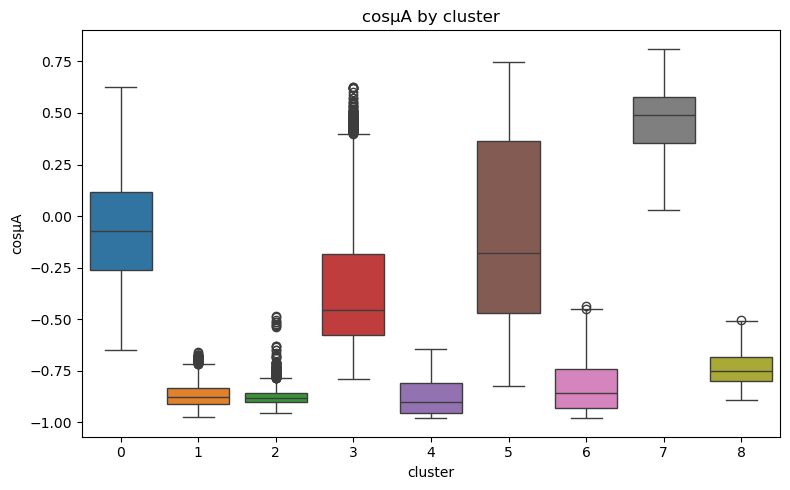

/var/folders/f1/8zx2wbhx4vb8626x_99mwyx40000gn/T/ipykernel_15321/503973969.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y=feat, data=df, palette="tab10")


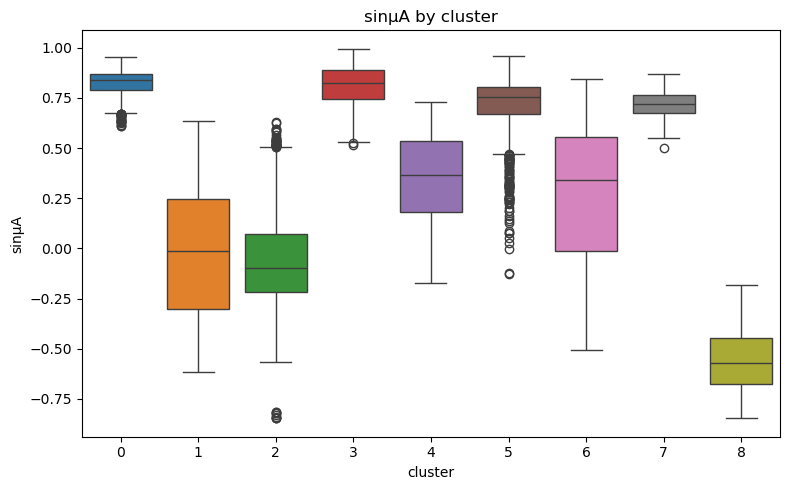

/var/folders/f1/8zx2wbhx4vb8626x_99mwyx40000gn/T/ipykernel_15321/503973969.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y=feat, data=df, palette="tab10")


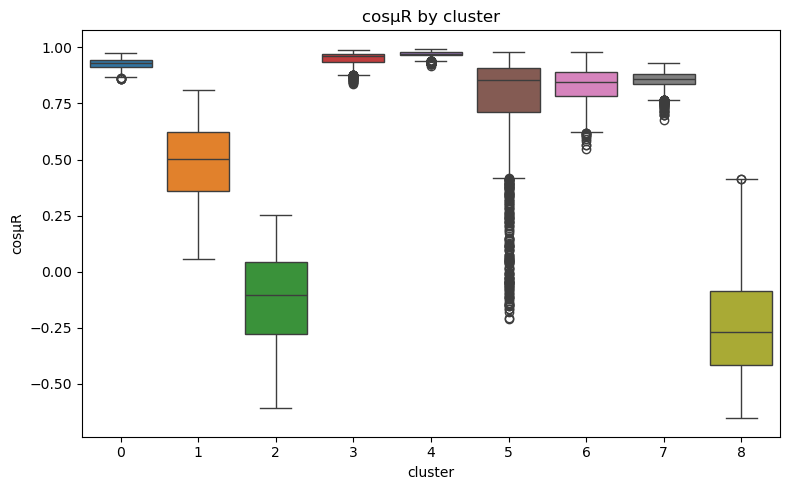

/var/folders/f1/8zx2wbhx4vb8626x_99mwyx40000gn/T/ipykernel_15321/503973969.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y=feat, data=df, palette="tab10")


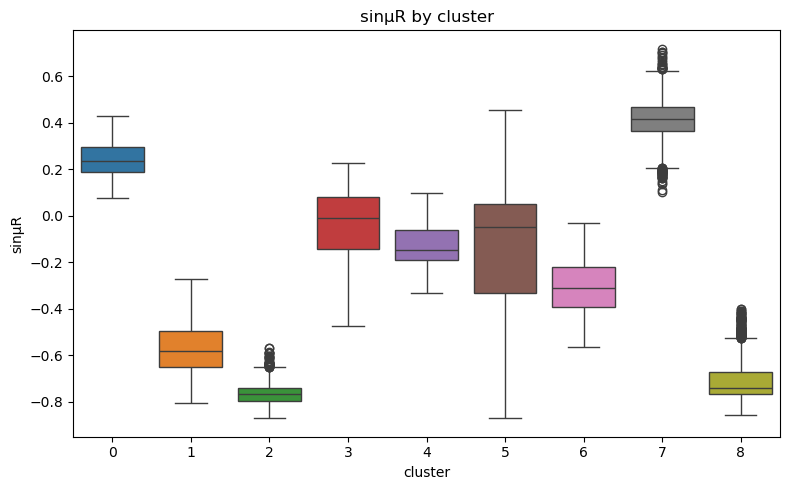

/var/folders/f1/8zx2wbhx4vb8626x_99mwyx40000gn/T/ipykernel_15321/503973969.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y=feat, data=df, palette="tab10")


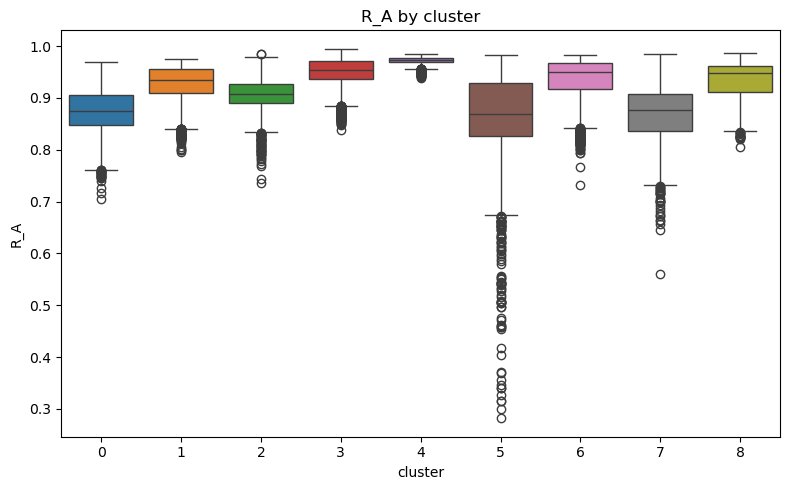

/var/folders/f1/8zx2wbhx4vb8626x_99mwyx40000gn/T/ipykernel_15321/503973969.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y=feat, data=df, palette="tab10")


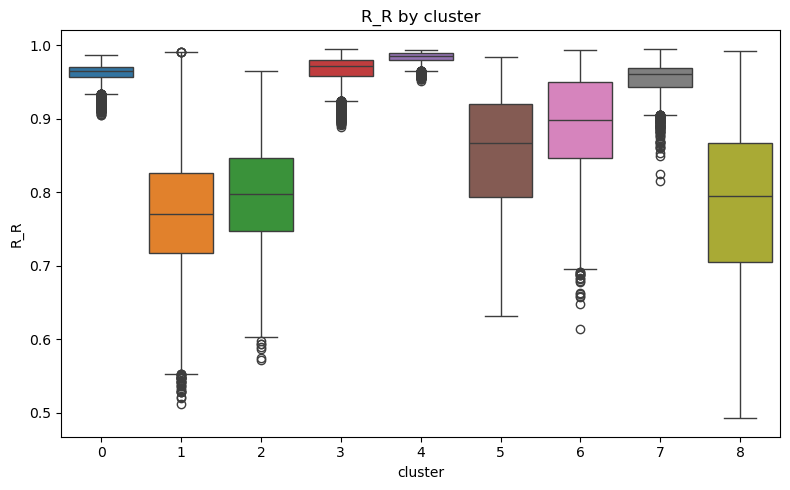

/var/folders/f1/8zx2wbhx4vb8626x_99mwyx40000gn/T/ipykernel_15321/503973969.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y=feat, data=df, palette="tab10")


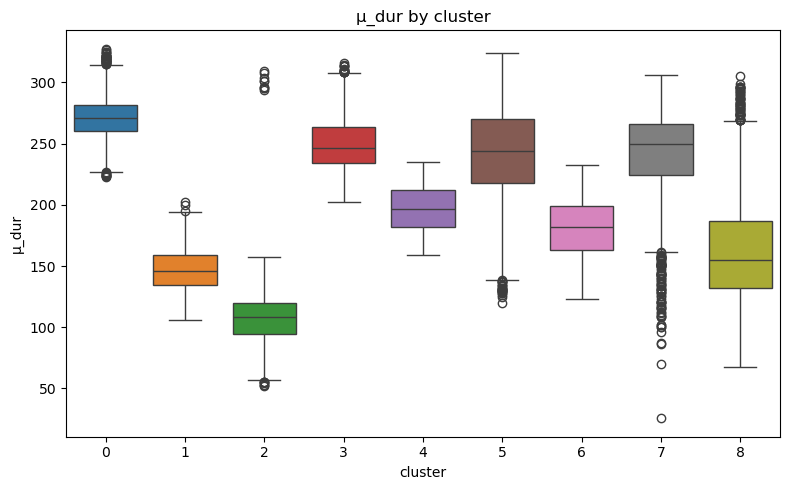

/var/folders/f1/8zx2wbhx4vb8626x_99mwyx40000gn/T/ipykernel_15321/503973969.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y=feat, data=df, palette="tab10")


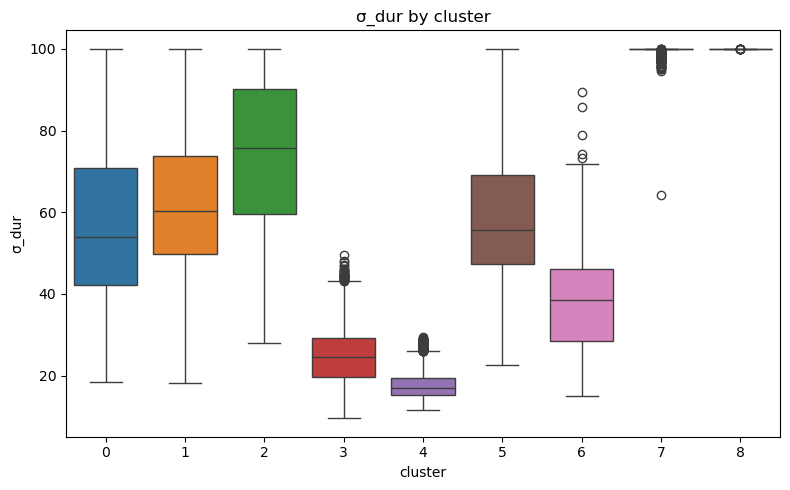

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot distributions for each feature across clusters
for feat in feature_names:
    plt.figure(figsize=(8,5))
    sns.boxplot(x="cluster", y=feat, data=df, palette="tab10")
    plt.title(f"{feat} by cluster")
    plt.tight_layout()
    plt.show()


In [18]:
# Assumes you already have:
#   df  -> DataFrame with columns ["cosμA","sinμA","cosμR","sinμR","R_A","R_R","μ_dur","σ_dur","cluster"]
#   P   -> period in days (365.0)
#   TAU -> 2π

import numpy as np

def angle_to_doy(theta):
    """theta in radians; return DOY in [0, P)."""
    return (theta % TAU) * (P / TAU)

def circ_std_days_from_R(R):
    """Circular std (radians) = sqrt(-2 ln R); convert to days."""
    # guard small numerical issues: clip R to (0,1]
    R = np.clip(R, 1e-12, 1.0)
    s_rad = np.sqrt(-2.0 * np.log(R))
    return s_rad * (P / TAU)

# Per-pixel mean angles (from cos/sin) -> DOY
df["μA_doy"] = angle_to_doy(np.arctan2(df["sinμA"], df["cosμA"]))
df["μR_doy"] = angle_to_doy(np.arctan2(df["sinμR"], df["cosμR"]))

# Per-pixel circular std (days) from R
df["σA_days"] = circ_std_days_from_R(df["R_A"].values)
df["σR_days"] = circ_std_days_from_R(df["R_R"].values)

df.head()


,cosμA,sinμA,cosμR,sinμR,R_A,R_R,μ_dur,σ_dur,cluster,μA_doy,μR_doy,σA_days,σR_days
0,-0.651561,-0.714671,-0.567949,-0.742393,0.967102,0.934726,179.192308,100.0,8,230.806523,235.813401,15.025658,21.344434
1,-0.624468,-0.739909,-0.561441,-0.750106,0.968207,0.936950,199.320000,100.0,8,233.028493,236.424479,14.766903,20.965440
2,-0.636753,-0.719760,-0.572801,-0.743126,0.960994,0.938263,184.629630,100.0,8,231.675271,235.602394,16.387091,20.738814
3,-0.634021,-0.727328,-0.540268,-0.749551,0.964878,0.923968,187.480000,100.0,8,232.100422,237.469400,15.534277,23.102367
4,-0.618743,-0.737998,-0.535602,-0.749858,0.963060,0.921497,186.360000,100.0,8,233.218032,237.719329,15.938688,23.490264


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

feature_names = ["μA_doy","μR_doy","σA_days","σR_days","μ_dur","σ_dur"]

# --- Circular mean helper (use vector average, not arithmetic mean) ---
def circ_mean_doy(doys):
    ang = (doys / P) * TAU
    C = np.nanmean(np.cos(ang))
    S = np.nanmean(np.sin(ang))
    theta = np.arctan2(S, C) % TAU
    return theta * (P / TAU)   # back to DOY

def circ_sd_days(doys):
    ang = (doys / P) * TAU
    C = np.nanmean(np.cos(ang))
    S = np.nanmean(np.sin(ang))
    R = np.hypot(C, S)
    R = np.clip(R, 1e-12, 1.0)
    s_rad = np.sqrt(-2.0 * np.log(R))
    return s_rad * (P / TAU)

# --- Build a per-cluster summary table ---
rows = []
for k, sub in df.groupby("cluster"):
    row = {
        "cluster": k,
        "N": len(sub),
        "μA_doy (circ mean)": circ_mean_doy(sub["μA_doy"].values),
        "μR_doy (circ mean)": circ_mean_doy(sub["μR_doy"].values),
        "σA_days (circ)":     circ_sd_days(sub["μA_doy"].values),
        "σR_days (circ)":     circ_sd_days(sub["μR_doy"].values),
        "R_A (mean)":         sub["R_A"].mean(),
        "R_R (mean)":         sub["R_R"].mean(),
        "μ_dur (mean)":       sub["μ_dur"].mean(),
        "σ_dur (mean)":       sub["σ_dur"].mean()
    }
    rows.append(row)

summary_tbl = pd.DataFrame(rows).sort_values("cluster").reset_index(drop=True)
print(summary_tbl.round(2))


   cluster     N  μA_doy (circ mean)  μR_doy (circ mean)  σA_days (circ)  \
0        0  4279               95.75               14.81           17.66   
1        1  3681              183.53              314.42           20.99   
2        2  2028              186.19              265.61           15.22   
3        3  3677              113.41              362.31           22.57   
4        4  3382              160.43              357.44           14.41   
5        5  1819               99.33              351.92           32.92   
6        6  3542              164.17              344.53           22.29   
7        7  2204               58.60               26.14           10.53   
8        8  3597              219.65              257.48           10.23   

   σR_days (circ)  R_A (mean)  R_R (mean)  μ_dur (mean)  σ_dur (mean)  
0            4.45        0.87        0.96        271.06         56.87  
1           13.54        0.93        0.77        146.68         61.73  
2           13.75      

/var/folders/f1/8zx2wbhx4vb8626x_99mwyx40000gn/T/ipykernel_15321/708206089.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="cluster", y="μA_doy", palette="tab10")


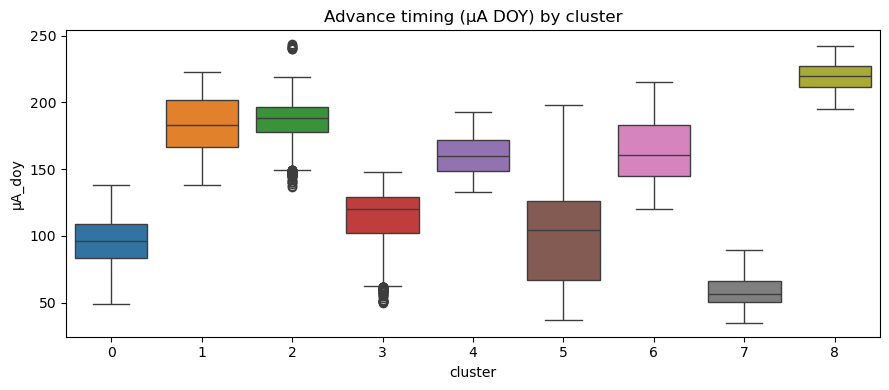

/var/folders/f1/8zx2wbhx4vb8626x_99mwyx40000gn/T/ipykernel_15321/708206089.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="cluster", y="μR_doy", palette="tab10")


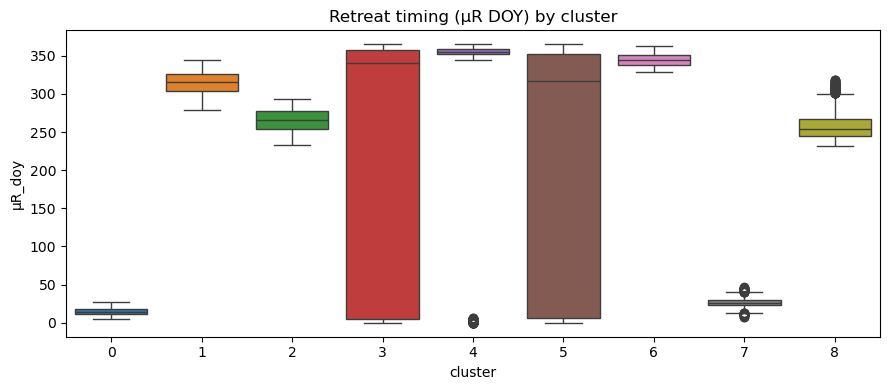

/var/folders/f1/8zx2wbhx4vb8626x_99mwyx40000gn/T/ipykernel_15321/708206089.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="cluster", y="σA_days", palette="tab10")


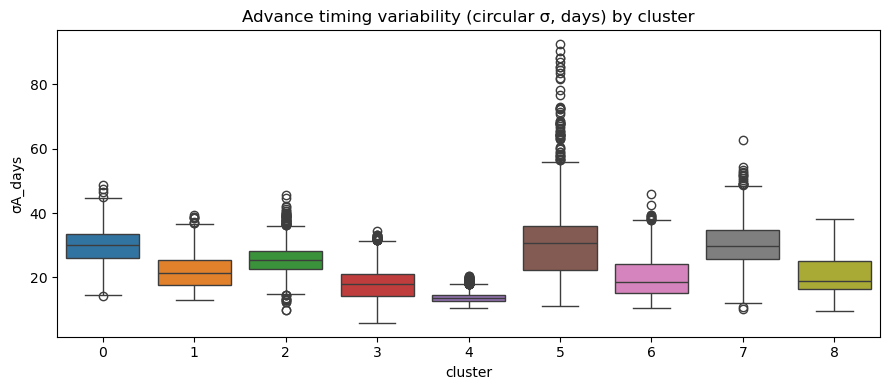

/var/folders/f1/8zx2wbhx4vb8626x_99mwyx40000gn/T/ipykernel_15321/708206089.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="cluster", y="σR_days", palette="tab10")


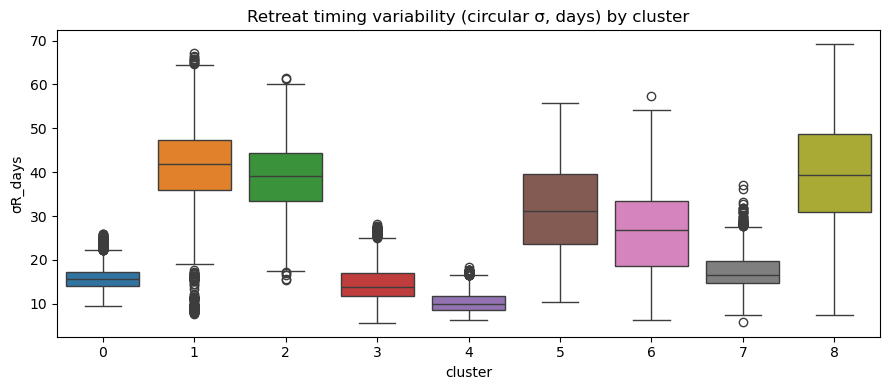

/var/folders/f1/8zx2wbhx4vb8626x_99mwyx40000gn/T/ipykernel_15321/708206089.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="cluster", y="μ_dur", palette="tab10")


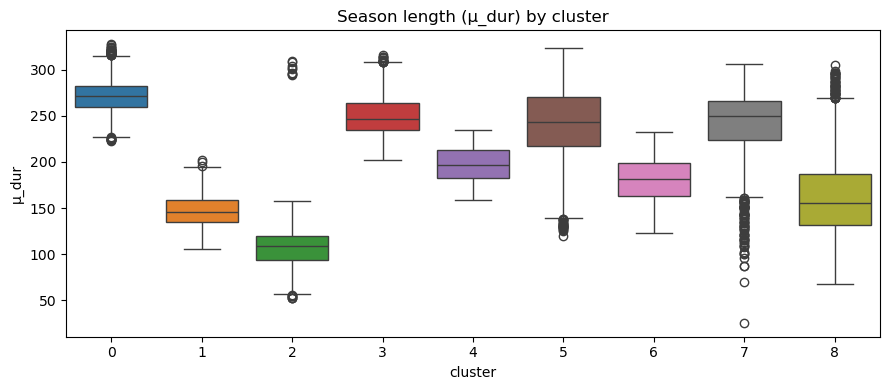

/var/folders/f1/8zx2wbhx4vb8626x_99mwyx40000gn/T/ipykernel_15321/708206089.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="cluster", y="σ_dur", palette="tab10")


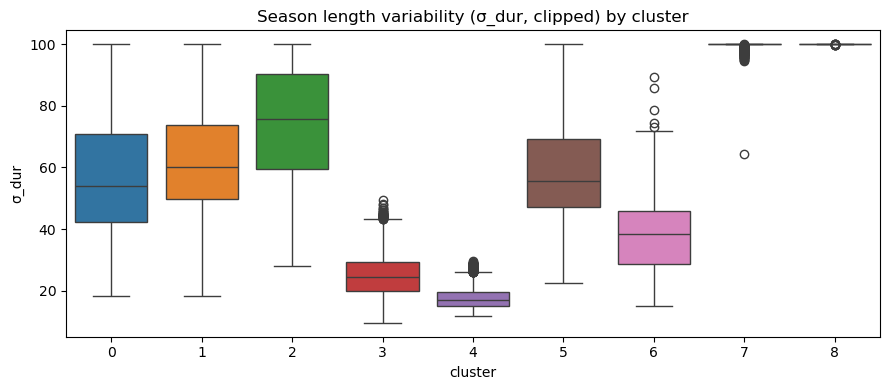

In [20]:
# Box/violin plots to see separation by cluster
plt.figure(figsize=(9,4))
sns.boxplot(data=df, x="cluster", y="μA_doy", palette="tab10")
plt.title("Advance timing (μA DOY) by cluster"); plt.tight_layout(); plt.show()

plt.figure(figsize=(9,4))
sns.boxplot(data=df, x="cluster", y="μR_doy", palette="tab10")
plt.title("Retreat timing (μR DOY) by cluster"); plt.tight_layout(); plt.show()

plt.figure(figsize=(9,4))
sns.boxplot(data=df, x="cluster", y="σA_days", palette="tab10")
plt.title("Advance timing variability (circular σ, days) by cluster"); plt.tight_layout(); plt.show()

plt.figure(figsize=(9,4))
sns.boxplot(data=df, x="cluster", y="σR_days", palette="tab10")
plt.title("Retreat timing variability (circular σ, days) by cluster"); plt.tight_layout(); plt.show()

plt.figure(figsize=(9,4))
sns.boxplot(data=df, x="cluster", y="μ_dur", palette="tab10")
plt.title("Season length (μ_dur) by cluster"); plt.tight_layout(); plt.show()

plt.figure(figsize=(9,4))
sns.boxplot(data=df, x="cluster", y="σ_dur", palette="tab10")
plt.title("Season length variability (σ_dur, clipped) by cluster"); plt.tight_layout(); plt.show()
